В това упражнение ще правим линейна регресия като изпозлваме библиотеката statsmodels. Първо имаме една клетка, в която стоят всички импорти:

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
import seaborn as sb # библиотека за чертаене на по-сложни графики. Използва matplotlib
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.gofplots import qqplot
import itertools
import math

## Свирене на щурци спрямо температурата
Ще разгледаме данните мощността на свирукането на щурци спрямо температурата. Първо зареждаме данните:

In [4]:
df = pd.read_excel('data/slr02.xls', engine = "xlrd")

*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'


In [5]:
df

,X,Y
0,20.000000,88.599998
1,16.000000,71.599998
2,19.799999,93.300003
3,18.400000,84.300003
4,17.100000,80.599998
5,15.500000,75.199997
6,14.700000,69.699997
7,17.100000,82.000000
8,15.400000,69.400002
9,16.200001,83.300003


In [6]:
df.columns = ['temp', 'noise']

In [7]:
df.shape

(15, 2)

Ще зползваме ols модела от [statsmodels](https://www.statsmodels.org/dev/index.html). Библиотеката statsmodels имплементира редица статистически модели. Ако изпозлваме обикновената имплементация на Ordinary Least Squares ([statsmodels.regression.linear_model.OLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html)]), подаваме данните като x и y аргументите на ols функцията. Ние ще изпозлваме имплементацията от [statsmodels.formula.api](https://www.statsmodels.org/dev/example_formulas.html), която ни позволява да зададем модела по подобен на R начин - като подадем формула за модел като string.

In [8]:
model = ols(formula='noise ~ temp', data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  noise   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     29.97
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           0.000107
Time:                        20:47:42   Log-Likelihood:                -40.348
No. Observations:                  15   AIC:                             84.70
Df Residuals:                      13   BIC:                             86.11
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     25.2323     10.060      2.508      0.026       3.499      46.966
temp           3.2911      0.601      5.475      0.000       1.992       4.590
==============================================================================
Omnibus:                        1.003   Durbin-Watson:                   1.818
Prob(Omnibus):                  0.606   Jarque-Bera (JB):                0.874
Skew:                          -0.391   Prob(JB):                        0.646
Kurtosis:                       2.114   Cond. No.                         171.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

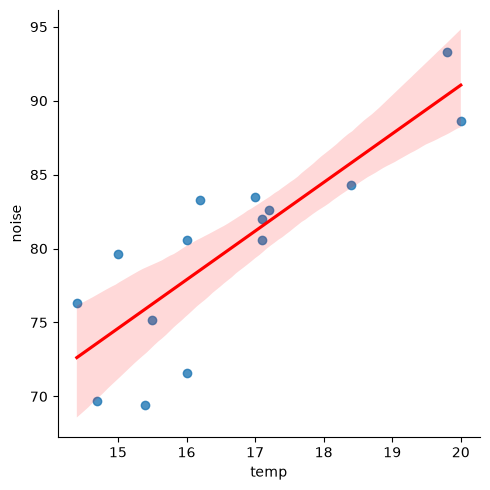

In [9]:
sb.lmplot(x='temp', y='noise', data=df, line_kws = {'color': 'red'})

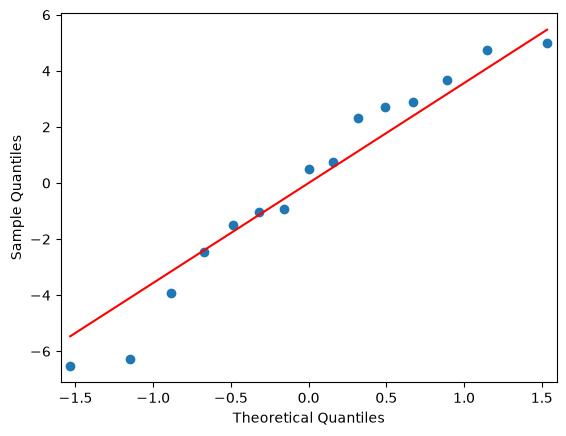

In [10]:
plot = qqplot(model.resid, line='s') # line='s' означава, че ще се изчертае права линия, която е най-добро приближение на теоретичната крива на нормалното разпределение за дадените данни

## Качество на червени вина

Файлът winequality-red.csv съдържа данни за редица характеристикина червени вина и оценка за виното от 1 до 10. Ще разгледаме дали как се справя модел на линейна регресия с тези данни.

In [11]:
df = pd.read_csv('data/winequality_red.csv', sep=';')

In [12]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


Понеже ще използваме формули за модела в стил R, трябва да нямаме спейсове в имената на колоните

In [13]:
df.columns = [c.replace(' ', '_') for c in df.columns]
df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

Можем да видим хистограма на точките

<Axes: ylabel='Frequency'>

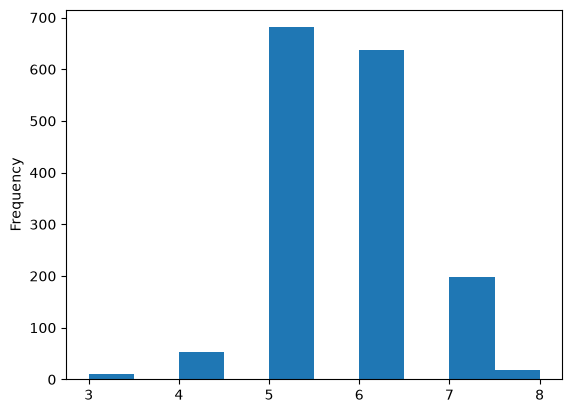

In [14]:
df.quality.plot.hist()

Понеже точките са числа, pandas не се сеща да подреди превилно биновете. Трябва да направим малко numpy магия, ако искаме графиката да е добре центрирана:

<Axes: ylabel='Frequency'>

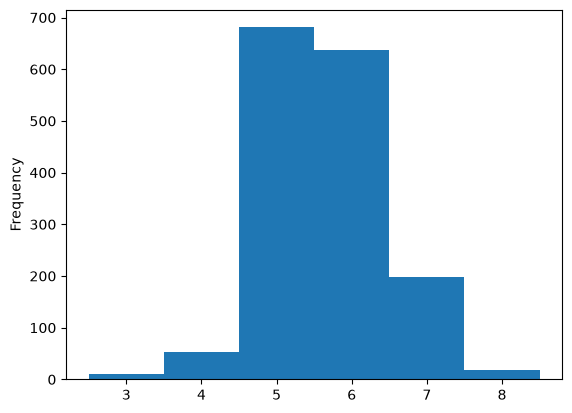

In [15]:
bins = np.arange(min(df.quality), max(df.quality) + 1.5) - 0.5 # биновете за 3 трябва да са 2.5 и 3.5 и ни трябва  един повече бин отколкото стойности имаме за точките
df.quality.plot.hist(bins=bins)

## Задача 1

Пресметнете средните, минималните и максималните стойности на променливите и ковариационната матрица. Имаме ли зависимости между предикторите? Има ли нужда да нормализираме променливите?

In [16]:
# Средни, минимални и максимални стойности
df.agg(['mean', 'min', 'max'])

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [17]:
# Koвариационна матрица
df.cov()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
fixed_acidity,3.031416,-0.079851,0.227820,0.281756,0.007679,-2.800921,-6.482346,0.002195,-0.183586,0.054010,-0.114421,0.174424
volatile_acidity,-0.079851,0.032062,-0.019272,0.000484,0.000517,-0.019674,0.450426,0.000007,0.006495,-0.007921,-0.038600,-0.056476
citric_acid,0.227820,-0.019272,0.037947,0.039434,0.001869,-0.124252,0.227697,0.000134,-0.016298,0.010328,0.022815,0.035612
residual_sugar,0.281756,0.000484,0.039434,1.987897,0.003690,2.758611,9.416441,0.000945,-0.018644,0.001321,0.063219,0.015635
chlorides,0.007679,0.000517,0.001869,0.003690,0.002215,0.002738,0.073387,0.000018,-0.001926,0.002962,-0.011092,-0.004900
free_sulfur_dioxide,-2.800921,-0.019674,-0.124252,2.758611,0.002738,109.414884,229.737521,-0.000433,0.113653,0.091592,-0.773698,-0.427907
total_sulfur_dioxide,-6.482346,0.450426,0.227697,9.416441,0.073387,229.737521,1082.102373,0.004425,-0.337699,0.239471,-7.209298,-4.917237
density,0.002195,0.000007,0.000134,0.000945,0.000018,-0.000433,0.004425,0.000004,-0.000100,0.000048,-0.000998,-0.000267
pH,-0.183586,0.006495,-0.016298,-0.018644,-0.001926,0.113653,-0.337699,-0.000100,0.023835,-0.005146,0.033832,-0.007198
sulphates,0.054010,-0.007921,0.010328,0.001321,0.002962,0.091592,0.239471,0.000048,-0.005146,0.028733,0.016907,0.034413


<Axes: >

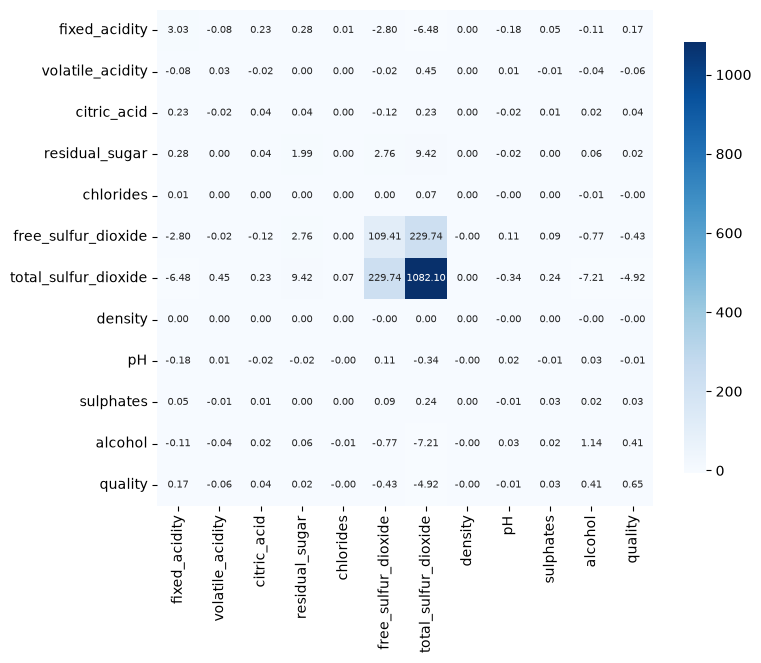

In [18]:
# За да видим визуално зависимостите може да използваме топлинен плот
plt.figure(figsize=(8,8))
sb.heatmap(df.cov(), annot=True, fmt='.2f', cmap='Blues', square=True, cbar_kws={'shrink': .7}, annot_kws={'size': 7})

<Axes: >

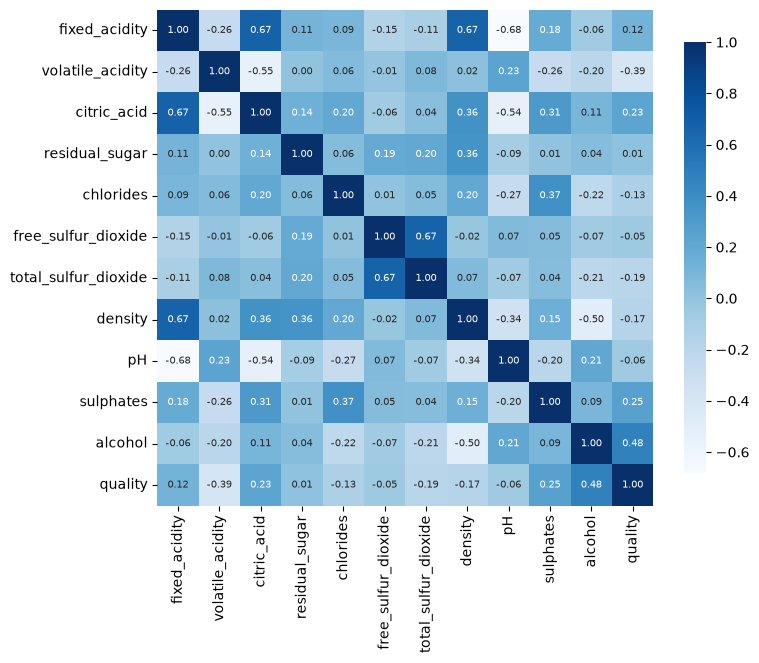

In [19]:
# Забележете, че някои стойности са много малки, а други много големи. Това е защото ковариацията между две променливи зависи от мащаба и мерните единици.
# Toест, ковариацията на две променливи в диапазона [0, 1] ще е много по-малка от ковариацията на две променливи в диапазона [0, 1000]. Това прави трудно сравняването на ковариационните коефициенти.
# За да можем да сравним ковариацията на две променливи с различен мащаб първо ще стандартизираме данните.
df_standardized = (df - df.mean()) / df.std()

plt.figure(figsize=(8,8))
sb.heatmap(df_standardized.cov(), annot=True, fmt='.2f', cmap='Blues', square=True, cbar_kws={'shrink': .7}, annot_kws={'size': 7})

<Axes: >

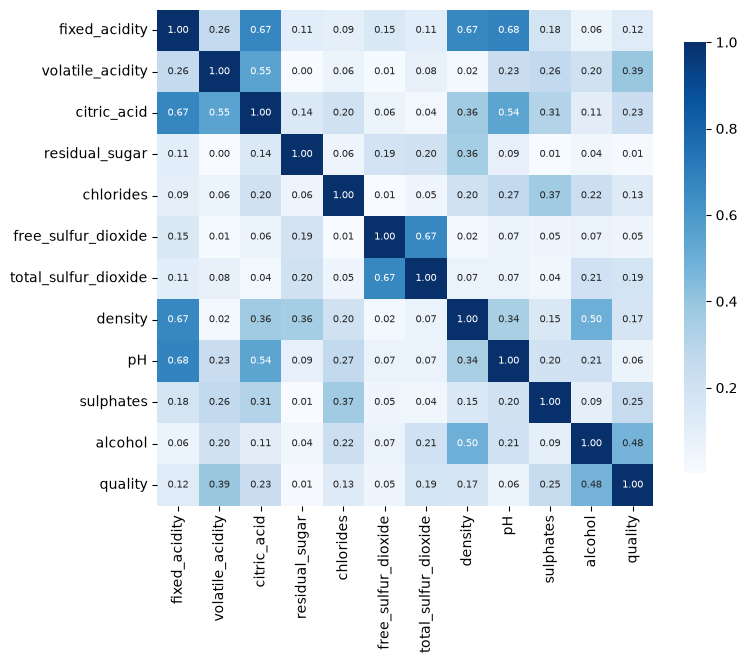

In [20]:
# За да отговорим на въпроса дали има зависимости, можем да използваме само абсолютната стойност на ковариацията. Така по ясно ще видим между кои променливи имат по-голяма зависимост:
cov = np.abs(df_standardized.cov())

plt.figure(figsize=(8, 8))
sb.heatmap(cov, annot=True, fmt='.2f', cmap='Blues', square=True, cbar_kws={'shrink': .7}, annot_kws={'size': 7})

<Axes: >

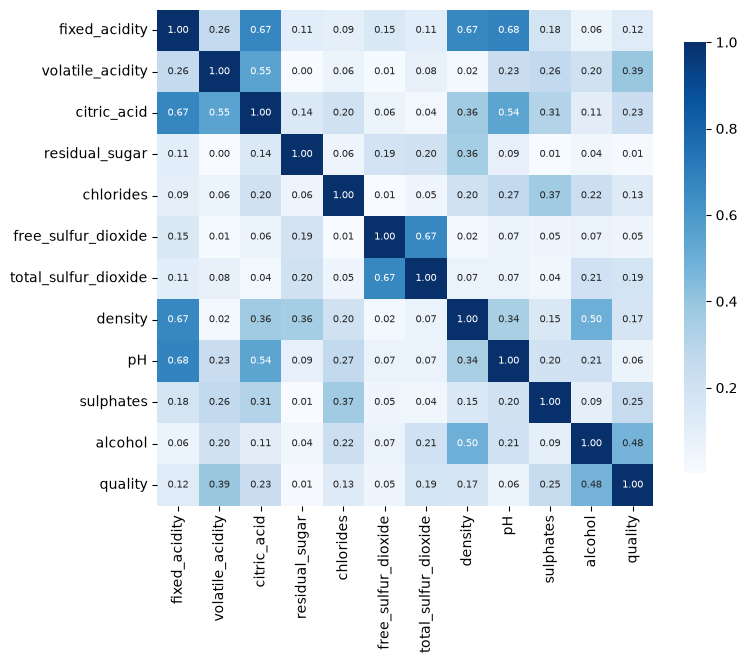

In [21]:
# Забележете, че в случая можехме да използваме и корелационната матрица с оригиналните данни, която е нормализираната ковариационна матрица.
corr = np.abs(df.corr())

plt.figure(figsize=(8, 8))
sb.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', square=True, cbar_kws={'shrink': .7}, annot_kws={'size': 7})

In [22]:
def collinear_variables(threshold: float):
    corr = np.abs(df.corr())
    corr = corr.mask(np.triu(np.ones(corr.shape, dtype=bool)), 0) # Mаскираме диагонала и горния триъгълник на матрицата, за да не се повтарят двойките променливи

    stack = corr.stack()

    collinear_variables = stack[stack > threshold] \
        .reset_index() \
        .rename(columns={'level_0': 'predictor 1', 'level_1': 'predictor 2', 0: 'abs_correlation'}) \
        .sort_values(by='abs_correlation', ascending=False) \
        .reset_index(drop=True) 

    return collinear_variables

# Ако изберем за граница на зависимост 0.3, то ще получим следните двойки променливи
collinear_variables(0.3)

,predictor 1,predictor 2,abs_correlation
0,pH,fixed_acidity,0.682978
1,citric_acid,fixed_acidity,0.671703
2,density,fixed_acidity,0.668047
3,total_sulfur_dioxide,free_sulfur_dioxide,0.667666
4,citric_acid,volatile_acidity,0.552496
5,pH,citric_acid,0.541904
6,alcohol,density,0.496180
7,quality,alcohol,0.476166
8,quality,volatile_acidity,0.390558
9,sulphates,chlorides,0.371260


## Задача 2
Скалирайте данните в интервала [0, +1].

In [23]:
df_minmax = df.copy()

mins = df_minmax.min()
maxs = df_minmax.max()

df_minmax = (df_minmax - mins) / (maxs - mins)

df_minmax.agg(['mean', 'min', 'max'])

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
mean,0.329171,0.279329,0.270976,0.112247,0.125988,0.209506,0.142996,0.490211,0.449695,0.196496,0.311228,0.527205
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Задача 3
Изградете линеен модел на регресия, използващ всички предиктори. Анализирайте резултата. Можем ли да премахнем някои предиктори от модела? Тествайте грешките на модела за нормалност.

Тук може да използваме възможността на манипулация на стрингове на python за да изградим тази формула без да трябва да пишем всички колони на таблицата на ръка.

In [24]:
def formula(target, predictors):
    return f'{target} ~ {' + '.join(predictors)}'

In [25]:
all_predictors = [c for c in df.columns if c != 'quality']

model = ols(formula=formula('quality', all_predictors), data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     81.35
Date:                Sat, 22 Aug 2026   Prob (F-statistic):          1.79e-145
Time:                        20:47:44   Log-Likelihood:                -1569.1
No. Observations:                1599   AIC:                             3162.
Df Residuals:                    1587   BIC:                             3227.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               21.9652     21.195      1.036      0.300     -19.607      63.538
fixed_acidity            0.0250      0.026      0.963      0.336      -0.026       0.076
volatile_acidity        -1.0836      0.121     -8.948      0.000      -1.321      -0.846
citric_acid             -0.1826      0.147     -1.240      0.215      -0.471       0.106
residual_sugar           0.0163      0.015      1.089      0.276      -0.013       0.046
chlorides               -1.8742      0.419     -4.470      0.000      -2.697      -1.052
free_sulfur_dioxide      0.0044      0.002      2.009      0.045       0.000       0.009
total_sulfur_dioxide    -0.0033      0.001     -4.480      0.000      -0.005      -0.002
density                -17.8812     21.633     -0.827      0.409     -60.314      24.551
pH                      -0.4137      0.192     -2.159      0.031      -0.789      -0.038
sulphates                0.9163      0.114      8.014      0.000       0.692       1.141
alcohol                  0.2762      0.026     10.429      0.000       0.224       0.328
==============================================================================
Omnibus:                       27.376   Durbin-Watson:                   1.757
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               40.965
Skew:                          -0.168   Prob(JB):                     1.27e-09
Kurtosis:                       3.708   Cond. No.                     1.13e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Получаваме $Adj. \ R^2 = 0.356$. Голяма част от коефициентите на предикторите са сигнификанти на нивото $0.05$.

Можем да опитаме да премахнем несигнификанти променливи или променливи с висока мултиколинеарност. 

1. Мултиколинеарните променливи пречат на интерпретацията на коефициентите. Трудно е да се каже дали коефициентите измерват чистия ефект на променливата $Х_i$ или съдържат и част от ефекта на $X_j$, за която важи $X_j = \gamma_{0} + \gamma_{1} X_i$.
2. Несигнификантите променливи "замръсяват" модела. Интересуваме се от най-простия модел на реалността, без да губим от прогнозиращата сила на модела.

In [26]:
# Разглеждаме кои променливи имат най-голяма зависимост с другите променливи
collinear_variables(0.5)

,predictor 1,predictor 2,abs_correlation
0,pH,fixed_acidity,0.682978
1,citric_acid,fixed_acidity,0.671703
2,density,fixed_acidity,0.668047
3,total_sulfur_dioxide,free_sulfur_dioxide,0.667666
4,citric_acid,volatile_acidity,0.552496
5,pH,citric_acid,0.541904


In [27]:
# Разглеждаме кои променливи са най-значими за модела, като сортираме по p-value
model.pvalues.sort_values(ascending=True)

alcohol                 1.123029e-24
volatile_acidity        9.872361e-19
sulphates               2.127228e-15
total_sulfur_dioxide    8.004610e-06
chlorides               8.373953e-06
pH                      3.100189e-02
free_sulfur_dioxide     4.474495e-02
citric_acid             2.149942e-01
residual_sugar          2.764960e-01
Intercept               3.001921e-01
fixed_acidity           3.356528e-01
density                 4.086079e-01
dtype: float64

In [28]:
# Премахвайки четирите най-незначими променливи, също премахнахме и много мултиколинеарни променливи.
manually_chosen_predictors = [c for c in all_predictors if c not in [
    'fixed_acidity',
    'density',
    'residual_sugar',
    'citric_acid',
]]

model1 = ols(formula=formula('quality', manually_chosen_predictors), data=df).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     127.6
Date:                Sat, 22 Aug 2026   Prob (F-statistic):          5.32e-149
Time:                        20:47:44   Log-Likelihood:                -1570.5
No. Observations:                1599   AIC:                             3157.
Df Residuals:                    1591   BIC:                             3200.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                4.4301      0.403     10.995      0.000       3.640       5.220
volatile_acidity        -1.0128      0.101    -10.043      0.000      -1.211      -0.815
chlorides               -2.0178      0.398     -5.076      0.000      -2.798      -1.238
free_sulfur_dioxide      0.0051      0.002      2.389      0.017       0.001       0.009
total_sulfur_dioxide    -0.0035      0.001     -5.070      0.000      -0.005      -0.002
pH                      -0.4827      0.118     -4.106      0.000      -0.713      -0.252
sulphates                0.8827      0.110      8.031      0.000       0.667       1.098
alcohol                  0.2893      0.017     17.225      0.000       0.256       0.322
==============================================================================
Omnibus:                       24.204   Durbin-Watson:                   1.750
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               35.245
Skew:                          -0.156   Prob(JB):                     2.22e-08
Kurtosis:                       3.657   Cond. No.                     1.71e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.71e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

След премахването на някои от несигнификантите и мултиколинеарни променливи получихме $Adj. \ R^2 = 0.357$. 

Забележете, че все още получаваме забележка че вероятно има и друг проблем:

> "The condition number is large, 1.71e+03. This might indicate that there are strong multicollinearity or other numerical problems."

В случая това съобщение е в следствие на нестандартизираните данни поради проблем в изчисляването при голями разлики в мащабите. Различните мащаби могат да попречат на пресмятането на $X^{-1}X$, което е ключово в линейната регресия. За да сме сигурни, че това не причинява проблеми, ще стандартизираме предикторите. Обикновено това не е нужно за стандартния линеен модел на регресията.

In [29]:
df_scaled = df.copy()
df_scaled[all_predictors] = (df_scaled[all_predictors] - df_scaled[all_predictors].mean()) / df_scaled[all_predictors].std()

model2 = ols(formula=formula('quality', manually_chosen_predictors), data=df_scaled).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.359
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     127.6
Date:                Sat, 22 Aug 2026   Prob (F-statistic):          5.32e-149
Time:                        20:47:44   Log-Likelihood:                -1570.5
No. Observations:                1599   AIC:                             3157.
Df Residuals:                    1591   BIC:                             3200.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                5.6360      0.016    347.932      0.000       5.604       5.668
volatile_acidity        -0.1813      0.018    -10.043      0.000      -0.217      -0.146
chlorides               -0.0950      0.019     -5.076      0.000      -0.132      -0.058
free_sulfur_dioxide      0.0531      0.022      2.389      0.017       0.010       0.097
total_sulfur_dioxide    -0.1145      0.023     -5.070      0.000      -0.159      -0.070
pH                      -0.0745      0.018     -4.106      0.000      -0.110      -0.039
sulphates                0.1496      0.019      8.031      0.000       0.113       0.186
alcohol                  0.3083      0.018     17.225      0.000       0.273       0.343
==============================================================================
Omnibus:                       24.204   Durbin-Watson:                   1.750
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               35.245
Skew:                          -0.156   Prob(JB):                     2.22e-08
Kurtosis:                       3.657   Cond. No.                         2.44
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

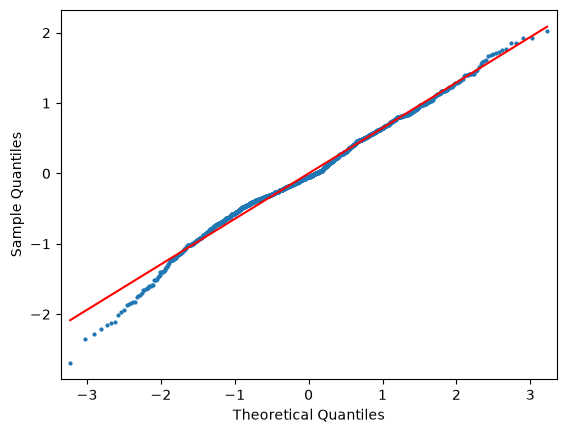

In [30]:
# Потвърждаваме, че грешките на модела са нормално разпределени, като разглеждаме Q-Q графиката.
plot = qqplot(model2.resid, line='s', markersize=2)

## Задача 4 *

Постройте всички възможни комбинации от предиктори и съответващите им модели. Намерете най-добрия модел само от гледна точка на squared sum of residuals. Намерете най-добрия модел само от гледна точка на adjusted R^2. По-добри ли са тези модели от ръчно избрания?

Можем да изпозлваме функцията [combinations](https://docs.python.org/3/library/itertools.html#itertools.combinations) от вградената библиотека itertools, за да генерираме всички комбинации с k елемента от един масив.

In [31]:
max_k = len(all_predictors)

summary = {
    'rsquared_adj': {},
    'ssr': {},
}

for k in range(1, max_k + 1):
    for combination in itertools.combinations(all_predictors, k):
        model = ols(formula=formula('quality', combination), data=df_scaled).fit()

        summary['rsquared_adj'][combination] = model.rsquared_adj
        summary['ssr'][combination] = model.ssr

In [32]:
combinations = list(summary['rsquared_adj'].keys())

rsquared_adj = np.array(list(summary['rsquared_adj'].values()))
ssr = np.array(list(summary['ssr'].values()))

rsquared_adj_max_idx = np.argmax(rsquared_adj)
ssr_min_idx = np.argmin(ssr)

print(f'Adj. R-squared: ')
print(f'---------------------------------')
print(f'Adj. R-squared: {rsquared_adj[rsquared_adj_max_idx]:.6f}')
print(f'SSR:            {ssr[rsquared_adj_max_idx]:.3f}')
print(f'Predictors:     {combinations[rsquared_adj_max_idx]}')

print()

print(f'SSR: ')
print(f'---------------------------------')
print(f'Adj. R-squared: {rsquared_adj[ssr_min_idx]:.6f}')
print(f'SSR:            {ssr[ssr_min_idx]:.3f}')
print(f'Predictors:     {combinations[ssr_min_idx]}')

print()

print(f'Manual: ')
print(f'---------------------------------')
print(f'Adj. R-squared: {model2.rsquared_adj:.6f}')
print(f'SSR:            {model2.ssr:.6f}')
print(f'Predictors:     {manually_chosen_predictors}')

Adj. R-squared: 
---------------------------------
Adj. R-squared: 0.356706
SSR:            667.062
Predictors:     ('volatile_acidity', 'citric_acid', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'pH', 'sulphates', 'alcohol')

SSR: 
---------------------------------
Adj. R-squared: 0.356119
SSR:            666.411
Predictors:     ('fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol')

Manual: 
---------------------------------
Adj. R-squared: 0.356653
SSR:            667.537059
Predictors:     ['volatile_acidity', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'pH', 'sulphates', 'alcohol']


От гледна точка на $Adj. \ R^2$ най-добрия модел е избрания от алгоритъма за сравнение на всички възможни комбинации. Това е нормално, но забележете, че в случая разликата е много малка, и че този модел съдържа повече променливи. Също така моделът съдържа променливите `citric_acid`, `volatile_acidity` и `pH` които са силно зависими. С други думи, съдържа повече двойки променливи със силна корелация, което прави интерпретацията на коефициентите по трудна.

# Задача 5. **

Какви са причините оценката $Adj. \ R^2$ да е толкова ниска? Кои свойства на линейната регресия са подходящи за този проблем и кои не? Бихме ли могли да трансформираме данните, така че да подобрим оценката на линейната регресия?



1. Линейната регресия предполага непрекъсната целева променлива. В нашия случай, тя е ординална, което означава, че винаги ще има остатъчна грешка, понеже линейната регресия дава реални числа като резултат. Въпреки това, използването на линеен модел на регресия е частично оправдан, понеже категориите са подредени. 
2. Линейната регресия предполага, че зависимостите са линейни (спрямо коефициентите). Когато използваме една линейна регресия във вид $Y = X \beta  = \beta_{0} + \beta_{1} X_1 + ... + \beta_{n} X_n$, ние автоматично предполагаме, че за промяна в $Х_i$, промяната в $Y$ е $\Delta Y = \beta_{i} \Delta X_i$.
3. Самите данни се отнасят до много субективна оценка, очаквано е да има голяма грешка в прогнозата.

In [39]:
# Точка 1. е частично оправдана.
# Разглеждаме точка 2.

# Ще направим графика на зависимостта между предикторите и качеството на виното, за да видим дали зависимостта е линейна.
def plot_predictors_vs_quality(df, predictors, lowess=False):
    row_count = math.ceil(len(predictors) / 3)
    col_count = 3

    _, axes = plt.subplots(math.ceil(len(predictors) / 3), 3, figsize=(col_count*3, row_count*3), layout='tight')

    for ridx in range(row_count):
        for cidx in range(col_count):
            predictor_idx = ridx * col_count + cidx

            ax = axes[cidx] if row_count == 1 else axes[ridx, cidx]
            if predictor_idx >= len(predictors):
                ax.axis('off')
                continue

            sb.regplot(x=predictors[predictor_idx], y='quality', data=df, line_kws = {'color': 'red'}, ax=ax, lowess=lowess)

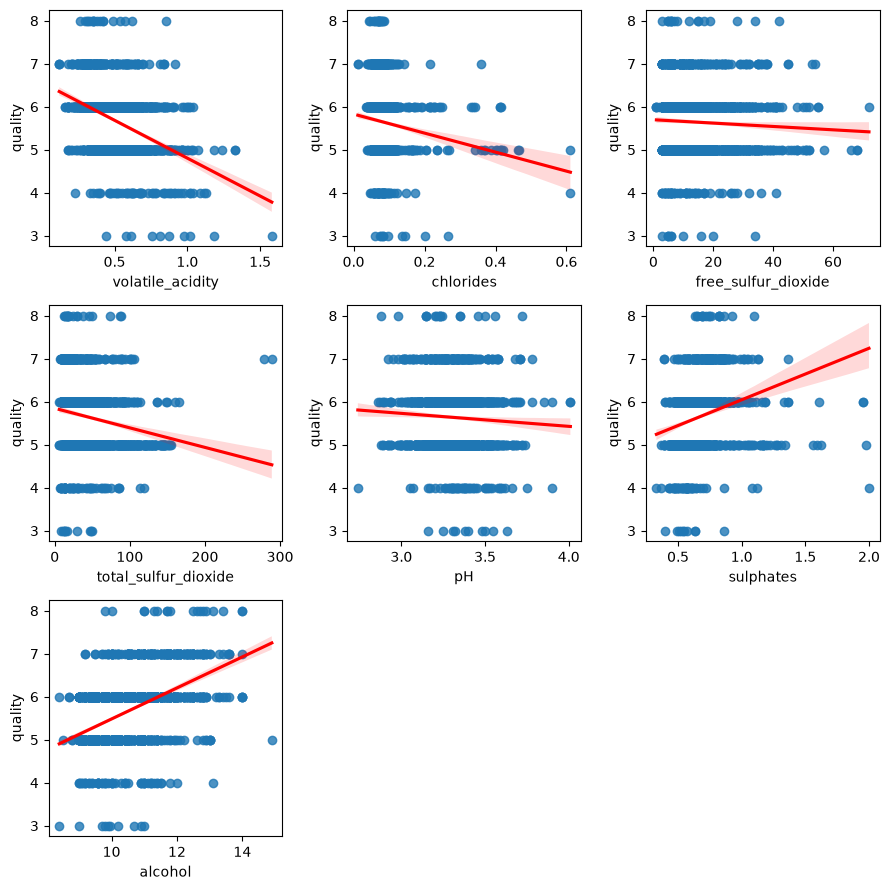

In [34]:
plot_predictors_vs_quality(df, manually_chosen_predictors)

От горните графики виждаме, че някои от променливитe показват по скоро експоненциална или логаритмична зависимост (но и това е спорно). Ще се опитаме да приложим трансформациите `log`, `log1p` и `exp` върху предикторите, за да видим дали ще имаме подобрение в $Adj. \ R^2$.

Започваме да прилагаме трансформациите на всяка променлива като всеки път сверяваме дали $Adj. \ R^2$ се е подобрило.

**Внимание:** възможно е да трансформираме и целевата променлива и това е честа практика, но за да сравним $Adj. \ R^2$ с предишните модели, трябва да запазим мащаба.

In [35]:
# Понеже ще използваме и логаритмични трансформации, ще използваме скалираните данни между 0 и 1.

df_transformed = df_minmax.copy()
df_transformed['volatile_acidity'] = np.exp(df_transformed['volatile_acidity'])
df_transformed['chlorides'] = np.exp(df_transformed['chlorides'])
df_transformed['free_sulfur_dioxide'] = np.log(df_transformed['free_sulfur_dioxide'] + 0.01)
df_transformed['total_sulfur_dioxide'] = np.exp(-df_transformed['total_sulfur_dioxide'])
df_transformed['pH'] = np.exp(df_transformed['pH'])
df_transformed['sulphates'] = np.log(df_transformed['sulphates'] + 0.01)
# df_transformed['alcohol']: нито една от разглежданите трансформации не дава по-добър резултат
# df_transformed['quality']: за да можем да сравним резултатите, не трябва да трансформираме целевата променлива

model3 = ols(formula=formula('quality', [c for c in manually_chosen_predictors]), data=df_transformed).fit()
model3.rsquared_adj

np.float64(0.3763816656418074)

Така съставения модел е:

$$
\begin{aligned}
Y = \beta_0 
&+ \beta_{\text{volatile\_acidity}} \cdot \exp(X_{\text{volatile\_acidity}}) \\
&+ \beta_{\text{chlorides}} \cdot \exp(X_{\text{chlorides}}) \\
&+ \beta_{\text{free\_sulfur\_dioxide}} \cdot \ln(X_{\text{free\_sulfur\_dioxide}} + 0.01) \\
&+ \beta_{\text{total\_sulfur\_dioxide}} \cdot \exp(-X_{\text{total\_sulfur\_dioxide}}) \\
&+ \beta_{\text{pH}} \cdot \exp(X_{\text{pH}}) \\
&+ \beta_{\text{sulphates}} \cdot \ln(X_{\text{sulphates}} + 0.01) \\
&+ \beta_{\text{alcohol}} \cdot X_{\text{alcohol}} + \varepsilon
\end{aligned}
$$

За да интерпретираме коефициентите правилно трябва да вземем в предвид формата на линейното уравнение горе.

$$
\begin{aligned}
\Delta Y_{\text{volatile\_acidity}} &\approx \beta_{\text{volatile\_acidity}} \cdot \exp(X_{\text{volatile\_acidity}}) \cdot \Delta X \\
\Delta Y_{\text{chlorides}} &\approx \beta_{\text{chlorides}} \cdot \exp(X_{\text{chlorides}}) \cdot \Delta X \\
\Delta Y_{\text{free\_sulfur\_dioxide}} &\approx \beta_{\text{free\_sulfur\_dioxide}} \frac{1}{X_{\text{free\_sulfur\_dioxide}} + 0.01} \cdot \Delta X \\
\Delta Y_{\text{total\_sulfur\_dioxide}} &\approx -\beta_{\text{total\_sulfur\_dioxide}} \cdot \exp(-X_{\text{total\_sulfur\_dioxide}}) \cdot \Delta X \\
\Delta Y_{\text{pH}} &\approx \beta_{\text{pH}} \cdot \exp(X_{\text{pH}}) \cdot \Delta X \\
\Delta Y_{\text{sulphates}} &\approx \beta_{\text{sulphates}} \frac{1}{X_{\text{sulphates}} + 0.01} \cdot \Delta X \\
\Delta Y_{\text{alcohol}} &\approx \beta_{\text{alcohol}} \cdot \Delta X
\end{aligned}
$$

In [36]:
model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     138.8
Date:                Sat, 22 Aug 2026   Prob (F-statistic):          1.05e-159
Time:                        20:47:54   Log-Likelihood:                 1027.9
No. Observations:                1599   AIC:                            -2040.
Df Residuals:                    1591   BIC:                            -1997.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.9257      0.063     14.731      0.000       0.802       1.049
volatile_acidity        -0.1884      0.021     -9.042      0.000      -0.229      -0.148
chlorides               -0.1622      0.031     -5.290      0.000      -0.222      -0.102
free_sulfur_dioxide      0.0215      0.006      3.324      0.001       0.009       0.034
total_sulfur_dioxide     0.2810      0.049      5.686      0.000       0.184       0.378
pH                      -0.0930      0.018     -5.121      0.000      -0.129      -0.057
sulphates                0.0833      0.008     10.271      0.000       0.067       0.099
alcohol                  0.3733      0.021     17.365      0.000       0.331       0.415
==============================================================================
Omnibus:                       25.370   Durbin-Watson:                   1.747
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.951
Skew:                          -0.154   Prob(JB):                     5.74e-09
Kurtosis:                       3.689   Cond. No.                         83.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

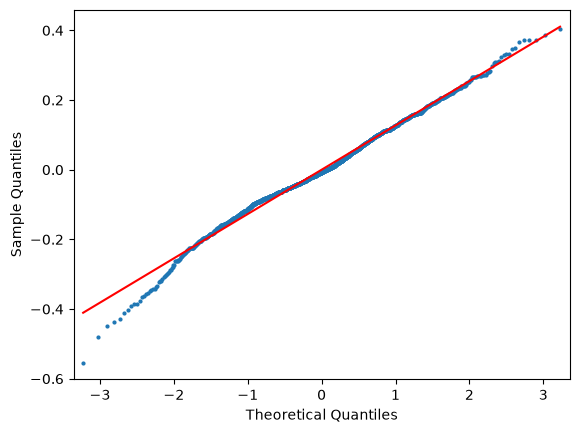

In [37]:
# Потвърждаваме, че грешките на модела са нормално разпределени, като разглеждаме Q-Q графиката.
plot = qqplot(model3.resid, line='s', markersize=2)

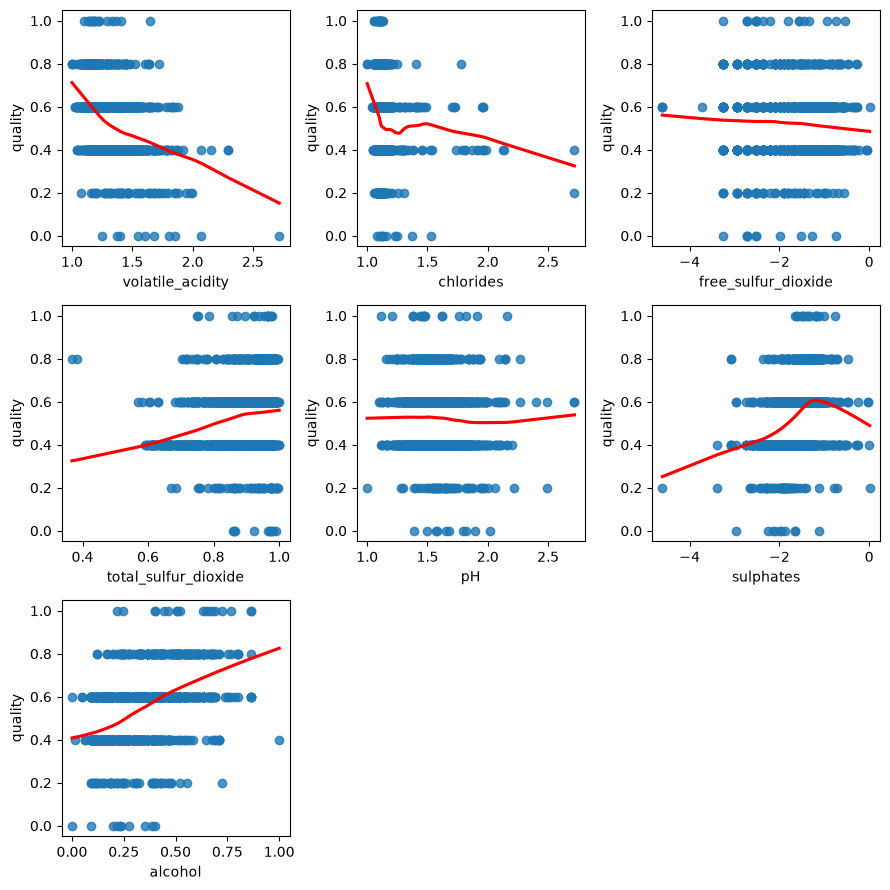

In [40]:
plot_predictors_vs_quality(df_transformed, manually_chosen_predictors, lowess=True)